In [1]:
# ====== 导入库 ======
import hashlib
import os
import tarfile
import zipfile
import requests

import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [5]:
# ====== 数据下载工具 ======
DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

def download(name, cache_dir='data'):
    """下载 DATA_HUB 中的数据集，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 DATA_HUB 中"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])

    # 校验缓存
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname

    # 下载
    print(f'正在下载 {url}')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname


In [6]:
# ====== 注册 Kaggle 房价数据 ======
DATA_HUB['kaggle_house_train'] = (
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce'
)

DATA_HUB['kaggle_house_test'] = (
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90'
)


In [7]:
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

print(train_data.shape)
print(test_data.shape)

正在下载 http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv
正在下载 http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv
(1460, 81)
(1459, 80)


In [9]:
print(train_data.iloc[0:4,[0,1,2,3,-3,-2,-1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [11]:
all_features=pd.concat((train_data.iloc[:,1:-1],test_data.iloc[:,1:]))

In [12]:
numeric_features=all_features.dtypes[all_features.dtypes!='object'].index
all_features[numeric_features]=all_features[numeric_features].apply(
        lambda x:(x-x.mean())/(x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0)

In [17]:
all_features=pd.get_dummies(all_features,dummy_na=True)
all_features=all_features.astype(float)
all_features.shape

(2919, 330)

In [22]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values,dtype=torch.float32)
test_features = torch.tensor(all_features[n_train:].values,dtype=torch.float32)
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1,1),dtype=torch.float32)

In [23]:
loss = nn.MSELoss()
in_features = train_features.shape[1]
def get_net():
    net = nn.Sequential(nn.Linear(in_features,1))
    return net

In [70]:
def log_rmse(net,features,labels):
    clipped_pred = torch.clamp(net(features),1,float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_pred),torch.log(labels)))
    return rmse.item()

In [76]:
def train(net,train_features,train_labels,test_features,test_labels,num_epochs,learning_rate,weight_decay,batch_szie):
    train_ls,test_ls=[],[]
    train_iter=d2l.load_array((train_features,train_labels),batch_size)
    optimizer = torch.optim.Adam(net.parameters(),lr=learning_rate,weight_decay=weight_decay)

    for epoch in range(num_epochs):
        for X,y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X),y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net,train_features,train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net,test_features,test_labels))
    return train_ls,test_ls    

In [77]:
def get_k_fold_data(k,i,X,y):
    assert k>1
    fold_size = X.shape[0]//k
    X_train,y_train = None,None
    for j in range(k):
        idx = slice(j*fold_size,(j+1)*fold_size)
        X_part,y_part=X[idx,:],y[idx]
        if j==i:
            X_valid,y_valid=X_part,y_part
        elif X_train is None:
            X_train,y_train=X_part,y_part
        else:
            X_train = torch.cat([X_train,X_part],0)
            y_train = torch.cat([y_train,y_part],0)
    return X_train,y_train,X_valid,y_valid        

In [78]:
import matplotlib.pyplot as plt

def plot_train_valid_rmse(train_ls, valid_ls, num_epochs):
    """
    train_ls: list，每个 epoch 的训练集 RMSE
    valid_ls: list，每个 epoch 的验证集 RMSE
    num_epochs: 训练轮数
    """

    epochs = list(range(1, num_epochs + 1))

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train_ls, label='train')
    plt.plot(epochs, valid_ls, label='valid')

    plt.xlabel('epoch')
    plt.ylabel('rmse')
    plt.xlim(1, num_epochs)
    plt.yscale('log')          # ★ 关键：纵轴取对数
    plt.legend()
    plt.grid(True)

    plt.show()
train_labels = train_labels.reshape(-1, 1)

In [83]:
def k_fold(k,X_train,y_train,num_epochs,learning_rate,weigth_decay,batch_szie):
    train_l_sum,valid_l_sum=0,0
    for i in range(k):
        data = get_k_fold_data(k,i,X_train,y_train)
        net = get_net()
        train_ls,valid_ls=train(net,*data,num_epochs,learning_rate,weight_decay,batch_size)
        train_l_sum+=train_ls[-1]
        valid_l_sum+=valid_ls[-1]
        if i ==0:
            plot_train_valid_rmse(train_ls,valid_ls,num_epochs)
        print(f'fold{i+1},train log rmse{float(train_ls[-1])},'f'valid log rmse{float(valid_ls[-1]):f}')
    return train_l_sum/k,valid_l_sum/k    

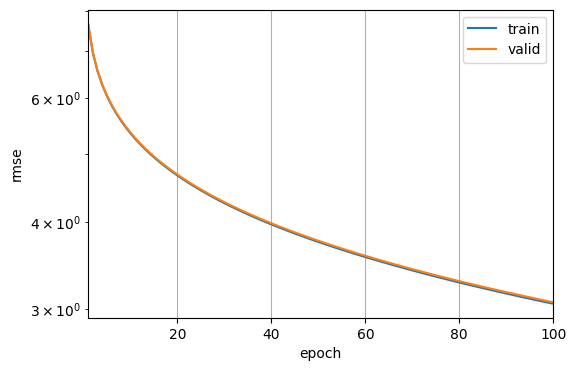

fold1,train log rmse3.0564932823181152,valid log rmse3.070734
fold2,train log rmse3.0563106536865234,valid log rmse3.067214
fold3,train log rmse3.0551321506500244,valid log rmse3.070309
fold4,train log rmse3.06406307220459,valid log rmse3.039641
fold5,train log rmse3.057725667953491,valid log rmse3.060757
5-折验证：平均训练log rmse:3.057945,平均验证log rmse:3.061731


In [92]:
k,num_epochs,lr,weight_decay,batch_size=5,100,0.1,1e-5,64
train_l,valid_l=k_fold(k,train_features,train_labels,num_epochs,lr,weight_decay,batch_size)
print(f'{k}-折验证：平均训练log rmse:{float(train_l):f},'f'平均验证log rmse:{float(valid_l):f}')